In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import json, re, os
from tqdm.auto import tqdm


In [2]:
fs = sorted(Path('../data/json2').glob('*.json'))
len(fs)

1074

In [3]:

def extract_links_re(s:str):
    return re.findall(r'\[.*?\]\((.*?)\)', s)
from collections import defaultdict
karma = defaultdict(int) # track score
gossip = defaultdict(list) # track number and content of comments... FIXME should include subcomments?
data = []
for f in fs:
    s = json.loads(f.open().read())

    for comment in s['comments']:
        links = extract_links_re(comment['body'])
        for l in links:
            karma[l] += comment['score'] / len(links)
            gossip[l].append(comment['body'])
        data += links

len(data)

7459

In [4]:
pd.Series(karma).sort_values(ascending=False).head(50)

https://redact.dev                                                                                                              139.000000
https://www.royalroad.com/fiction/81002/the-years-of-apocalypse-a-time-loop-progression                                         117.305556
https://www.fanfiction.net/s/10677106/1/Seventh-Horcrux                                                                          97.312500
https://www.youtube.com/watch?v=OfJRm0WssOE                                                                                      97.000000
https://www.royalroad.com/fiction/41330/virtuous-sons-a-greco-roman-xianxia                                                      86.500000
https://www.royalroad.com/fiction/21410/super-minion                                                                             84.116667
http://unsongbook.com/                                                                                                           70.909091
https://www.royalroad.com/f

In [5]:
df_links = pd.Series(data).value_counts()
df_links.shape

(6090,)

In [17]:
blocklist = [
#   'reddit',
    'redact', 'pastebin', 'wikipedia', 'docs.google', 'discord','tvtropes.org', 'ask_wikibot']

allowlist = ['hfy']
df_links = df_links[~df_links.index.str.contains('|'.join(blocklist), regex=True) | df_links.index.str.contains('|'.join(allowlist), regex=True)]
df_links = df_links[df_links.index.str.startswith('http')]
df_links = df_links[df_links > 1]
pd.Series(df_links.index, index=df_links.values)

13    https://www.royalroad.com/fiction/21410/super-...
12    http://www.np.reddit.com/r/autowikibot/comment...
12    http://www.np.reddit.com/r/autowikibot/wiki/index
12                 https://www.fanfiction.net/s/5193644
12    https://www.royalroad.com/fiction/26727/arkend...
                            ...                        
2                       https://i.imgur.com/ySl1dFj.png
2     https://www.royalroad.com/fiction/68630/dark-l...
2     https://www.royalroad.com/fiction/40920/the-pa...
2     https://www.royalroad.com/fiction/32807/dark-s...
2     https://www.royalroad.com/fiction/32411/bens-d...
Length: 606, dtype: object

TODO
- [ ] dedup
- [ ] convert to title

<Axes: ylabel='Frequency'>

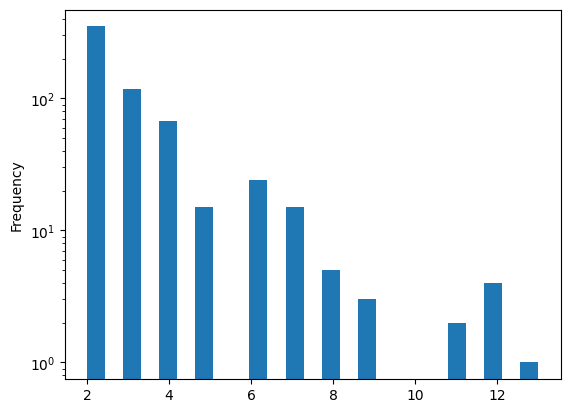

In [18]:
df_links.plot.hist(bins=25, logy=True)

In [19]:
df_links.to_markdown('../outputs/links2.md')

# Get title

In [20]:
# import shutil
# shutil.rmtree(f_cache)

In [21]:
from anycache import anycache
f_cache = Path('../outputs/.anycache')

from pathlib import Path
import requests
from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from requests.packages.urllib3.util.retry import Retry

f_cache = Path('../outputs/.anycache')

def requests_retry_session(
    retries=3,
    backoff_factor=0.3,
    status_forcelist=(500, 502, 504),
    session=None,
):
    session = session or requests.Session()
    retry = Retry(
        total=retries,
        read=retries,
        connect=retries,
        backoff_factor=backoff_factor,
        status_forcelist=status_forcelist,
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('http://', adapter)
    session.mount('https://', adapter)
    return session

session = requests_retry_session()
session.headers['User-Agent'] = 'Mozilla/5.0'

@anycache(f_cache)
def get_title(url):
    try:
        r = session.get(url, timeout=5, allow_redirects=True)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, 'html.parser')
        title = soup.title.text.strip()
        return title
    except Exception as e:
        raise e  

url = df_links.index[0]
r = get_title(url)
r


'Super Minion | Royal Road'

FIXME:
- banned from fanfiction.net
-  https://www.fictionpress.com

In [23]:
data2 = []
for i in tqdm(range(len(df_links))):
    url = df_links.index[i]
    try:
        title = get_title(url)
    except Exception as e:
        print(f'failed to get title for {url}: {e}')
        title = ''
    comments = gossip[url]
    score = karma[url]
    num_comments = len(comments)
    data2.append(dict(url=url, title=title, score=score, comments=comments, num_comments=num_comments))

df2 = pd.DataFrame(data2)
df2

  0%|          | 0/606 [00:00<?, ?it/s]

failed to get title for http://www.np.reddit.com/r/autowikibot/comments/1x013o/for_moderators_switches_commands_and_css/: HTTPSConnectionPool(host='www.np.reddit.com', port=443): Max retries exceeded with url: /r/autowikibot/comments/1x013o/for_moderators_switches_commands_and_css/ (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'www.np.reddit.com'. (_ssl.c:1007)")))
failed to get title for http://www.np.reddit.com/r/autowikibot/wiki/index: HTTPSConnectionPool(host='www.np.reddit.com', port=443): Max retries exceeded with url: /r/autowikibot/wiki/index (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'www.np.reddit.com'. (_ssl.c:1007)")))
failed to get title for https://www.fanfiction.net/s/5193644: 403 Client Error: Forbidden for url: https://www.fanfiction.net/s/5193644


KeyboardInterrupt: 

In [ ]:
# dedup using title
# TODO add comments
df3 = df2.groupby('title').sum().sort_values('score', ascending=False)
df3

In [ ]:
df2.shape, df3.shape

## Extra get a llm summary of each link

Grab all md's that mention a story, ask claude to summarize

We could also get total karma per mention